## 1. Import Required Libraries

In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, classification_report, 
                             roc_auc_score, roc_curve, f1_score, 
                             precision_score, recall_score)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("Libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")

Libraries imported successfully!
TensorFlow version: 2.21.0


## 2. Load and Explore Dataset

Load the credit card fraud detection dataset and perform exploratory data analysis to understand the data structure, features, and class distribution.

In [2]:
# Load the dataset
df = pd.read_csv('creditcard.csv')

# Display basic information
print("Dataset Shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nBasic Statistics:")
print(df.describe())

Dataset Shape: (284807, 31)

First few rows:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -


Missing Values:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Class Proportion:
Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64


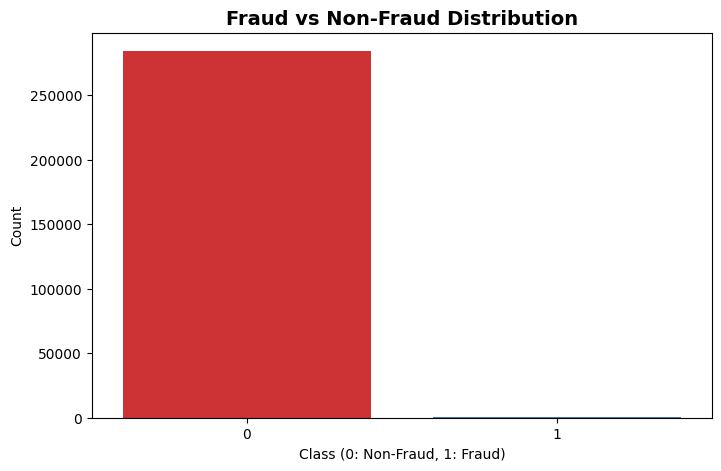


Number of duplicate rows: 1081


In [3]:
# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Check class distribution
print("\nClass Distribution:")
print(df['Class'].value_counts())
print("\nClass Proportion:")
print(df['Class'].value_counts(normalize=True))

# Visualize class distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Class', palette='Set1')
plt.title('Fraud vs Non-Fraud Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Class (0: Non-Fraud, 1: Fraud)')
plt.ylabel('Count')
plt.show()

# Check for duplicates
print(f"\nNumber of duplicate rows: {df.duplicated().sum()}")

## 2.5 Visualize Fraud vs Non-Fraud Transactions

Compare the characteristics of fraudulent and legitimate transactions to understand patterns.

In [4]:
# Separate fraud and non-fraud transactions
fraud_transactions = df[df['Class'] == 1]
legit_transactions = df[df['Class'] == 0]

print("TRANSACTION BREAKDOWN:")
print("=" * 60)
print(f"\n🟢 Legitimate Transactions:")
print(f"   Count: {len(legit_transactions):,}")
print(f"   Percentage: {len(legit_transactions)/len(df)*100:.2f}%")

print(f"\n🔴 Fraudulent Transactions:")
print(f"   Count: {len(fraud_transactions):,}")
print(f"   Percentage: {len(fraud_transactions)/len(df)*100:.2f}%")

# Show example of a FRAUDULENT transaction
print("\n" + "=" * 60)
print("EXAMPLE: FRAUDULENT TRANSACTION 🔴")
print("=" * 60)
fraud_example = fraud_transactions.iloc[0]
print(fraud_example.to_string())

# Show example of a LEGITIMATE transaction
print("\n" + "=" * 60)
print("EXAMPLE: LEGITIMATE TRANSACTION 🟢")
print("=" * 60)
legit_example = legit_transactions.iloc[0]
print(legit_example.to_string())

TRANSACTION BREAKDOWN:

🟢 Legitimate Transactions:
   Count: 284,315
   Percentage: 99.83%

🔴 Fraudulent Transactions:
   Count: 492
   Percentage: 0.17%

EXAMPLE: FRAUDULENT TRANSACTION 🔴
Time      406.000000
V1         -2.312227
V2          1.951992
V3         -1.609851
V4          3.997906
V5         -0.522188
V6         -1.426545
V7         -2.537387
V8          1.391657
V9         -2.770089
V10        -2.772272
V11         3.202033
V12        -2.899907
V13        -0.595222
V14        -4.289254
V15         0.389724
V16        -1.140747
V17        -2.830056
V18        -0.016822
V19         0.416956
V20         0.126911
V21         0.517232
V22        -0.035049
V23        -0.465211
V24         0.320198
V25         0.044519
V26         0.177840
V27         0.261145
V28        -0.143276
Amount      0.000000
Class       1.000000

EXAMPLE: LEGITIMATE TRANSACTION 🟢
Time        0.000000
V1         -1.359807
V2         -0.072781
V3          2.536347
V4          1.378155
V5         -0.338321

In [5]:
# Compare key features between fraud and legitimate transactions
print("\nCOMPARISON OF KEY FEATURES:")
print("=" * 80)

# Get numerical columns (exclude Time and Class)
numerical_cols = [col for col in df.columns if col not in ['Time', 'Class']]

# Calculate statistics for fraud vs non-fraud
comparison = pd.DataFrame({
    'Fraud_Mean': fraud_transactions[numerical_cols].mean(),
    'Legit_Mean': legit_transactions[numerical_cols].mean(),
    'Fraud_Std': fraud_transactions[numerical_cols].std(),
    'Legit_Std': legit_transactions[numerical_cols].std()
})

# Show first 10 features
print("\nFirst 10 Features - Mean Values Comparison:")
print(comparison.head(10).to_string())

print("\n(Showing fraud vs legitimate transaction patterns in features)")
print("Note: PCA-transformed features (V1-V28) show different patterns for fraud")


COMPARISON OF KEY FEATURES:

First 10 Features - Mean Values Comparison:
     Fraud_Mean  Legit_Mean  Fraud_Std  Legit_Std
V1    -4.771948    0.008258   6.783687   1.929814
V2     3.623778   -0.006271   4.291216   1.636146
V3    -7.033281    0.012171   7.110937   1.459429
V4     4.542029   -0.007860   2.873318   1.399333
V5    -3.151225    0.005453   5.372468   1.356952
V6    -1.397737    0.002419   1.858124   1.329913
V7    -5.568731    0.009637   7.206773   1.178812
V8     0.570636   -0.000987   6.797831   1.161283
V9    -2.581123    0.004467   2.500896   1.089372
V10   -5.676883    0.009824   4.897341   1.044204

(Showing fraud vs legitimate transaction patterns in features)
Note: PCA-transformed features (V1-V28) show different patterns for fraud


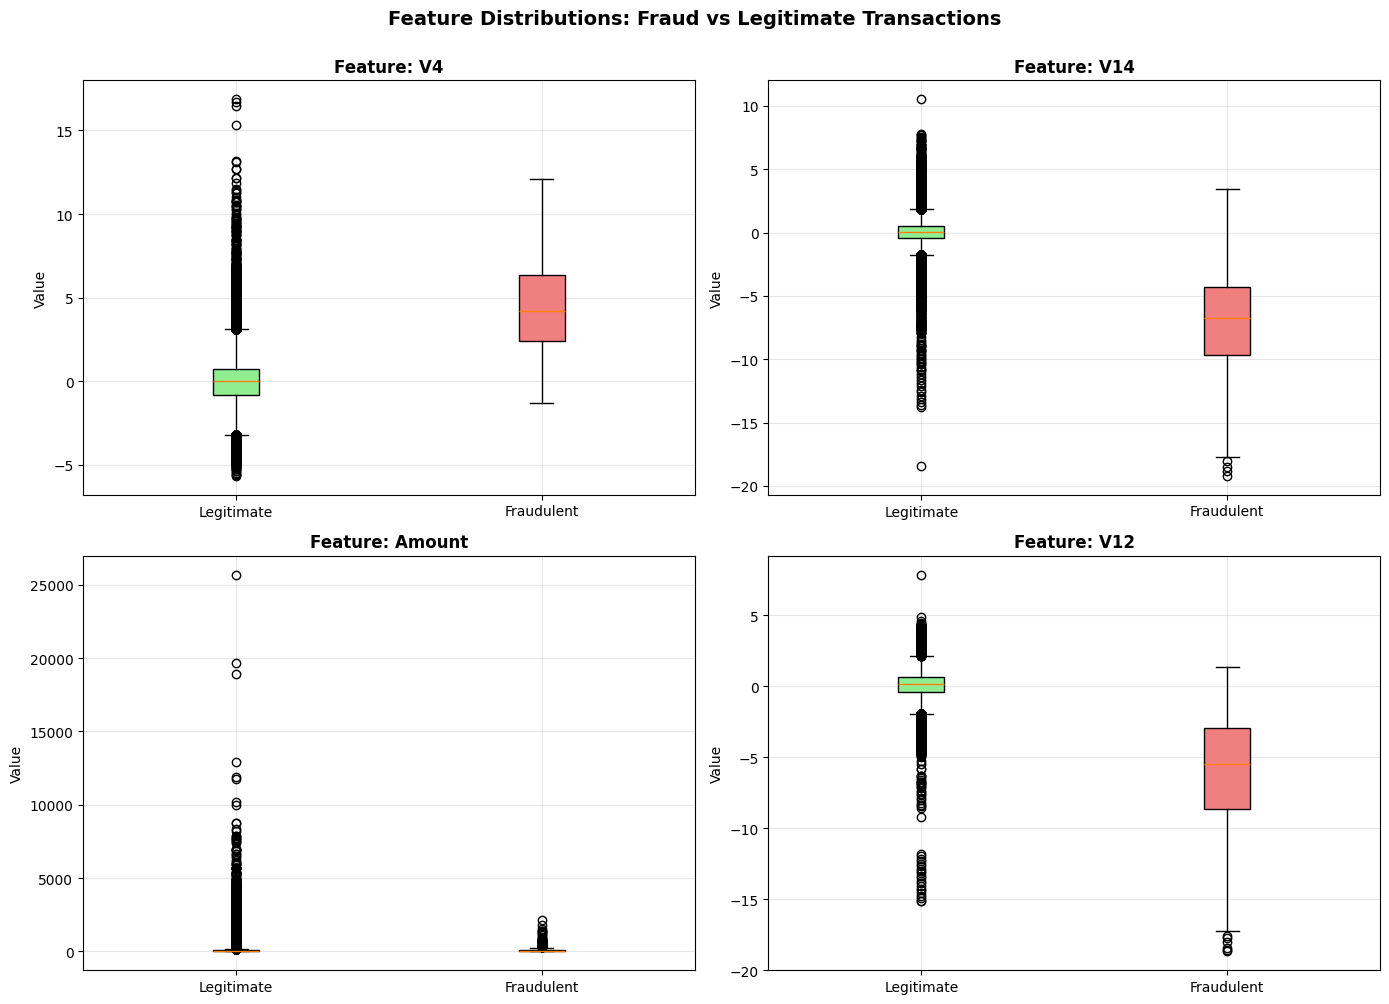


✅ Green boxes = Legitimate transactions
✅ Red boxes = Fraudulent transactions

Notice: Fraudulent transactions have different feature distributions!


In [6]:
# Visualize distribution differences for selected features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Select 4 features that show good difference between fraud and legit
features_to_plot = ['V4', 'V14', 'Amount', 'V12']

for idx, feature in enumerate(features_to_plot):
    ax = axes[idx // 2, idx % 2]
    
    # Create box plot
    data_to_plot = [legit_transactions[feature], fraud_transactions[feature]]
    bp = ax.boxplot(data_to_plot, labels=['Legitimate', 'Fraudulent'], patch_artist=True)
    
    # Color the boxes
    colors = ['lightgreen', 'lightcoral']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    
    ax.set_title(f'Feature: {feature}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Value')
    ax.grid(True, alpha=0.3)

plt.suptitle('Feature Distributions: Fraud vs Legitimate Transactions', 
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("\n✅ Green boxes = Legitimate transactions")
print("✅ Red boxes = Fraudulent transactions")
print("\nNotice: Fraudulent transactions have different feature distributions!")

In [7]:
# Show sample fraudulent transactions
print("\n" + "=" * 100)
print("SAMPLE FRAUDULENT TRANSACTIONS (First 5)")
print("=" * 100)
fraud_sample = fraud_transactions[['Time', 'Amount', 'Class']].head(5)
print(fraud_sample.to_string())

print("\n" + "=" * 100)
print("SAMPLE LEGITIMATE TRANSACTIONS (First 5)")
print("=" * 100)
legit_sample = legit_transactions[['Time', 'Amount', 'Class']].head(5)
print(legit_sample.to_string())

# Amount statistics
print("\n" + "=" * 100)
print("TRANSACTION AMOUNT STATISTICS")
print("=" * 100)
print(f"\n🟢 LEGITIMATE TRANSACTIONS:")
print(f"   Mean Amount:     ${legit_transactions['Amount'].mean():.2f}")
print(f"   Median Amount:   ${legit_transactions['Amount'].median():.2f}")
print(f"   Min Amount:      ${legit_transactions['Amount'].min():.2f}")
print(f"   Max Amount:      ${legit_transactions['Amount'].max():.2f}")
print(f"   Std Dev:         ${legit_transactions['Amount'].std():.2f}")

print(f"\n🔴 FRAUDULENT TRANSACTIONS:")
print(f"   Mean Amount:     ${fraud_transactions['Amount'].mean():.2f}")
print(f"   Median Amount:   ${fraud_transactions['Amount'].median():.2f}")
print(f"   Min Amount:      ${fraud_transactions['Amount'].min():.2f}")
print(f"   Max Amount:      ${fraud_transactions['Amount'].max():.2f}")
print(f"   Std Dev:         ${fraud_transactions['Amount'].std():.2f}")


SAMPLE FRAUDULENT TRANSACTIONS (First 5)
        Time  Amount  Class
541    406.0    0.00      1
623    472.0  529.00      1
4920  4462.0  239.93      1
6108  6986.0   59.00      1
6329  7519.0    1.00      1

SAMPLE LEGITIMATE TRANSACTIONS (First 5)
   Time  Amount  Class
0   0.0  149.62      0
1   0.0    2.69      0
2   1.0  378.66      0
3   1.0  123.50      0
4   2.0   69.99      0

TRANSACTION AMOUNT STATISTICS

🟢 LEGITIMATE TRANSACTIONS:
   Mean Amount:     $88.29
   Median Amount:   $22.00
   Min Amount:      $0.00
   Max Amount:      $25691.16
   Std Dev:         $250.11

🔴 FRAUDULENT TRANSACTIONS:
   Mean Amount:     $122.21
   Median Amount:   $9.25
   Min Amount:      $0.00
   Max Amount:      $2125.87
   Std Dev:         $256.68


## 3. Preprocess and Normalize Data

Handle missing values, remove duplicates, and normalize features using StandardScaler to ensure all features are on the same scale.

In [8]:
# Remove duplicates
df = df.drop_duplicates()
print(f"Shape after removing duplicates: {df.shape}")

# Separate features and target
X = df.drop('Class', axis=1)
y = df['Class']

# Handle missing values (if any)
X = X.fillna(X.mean())

# Normalize the features using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\nFeatures shape: {X_scaled.shape}")
print(f"Target shape: {y.shape}")
print(f"\nScaled features - Mean: {X_scaled.mean(axis=0).round(4)}")
print(f"Scaled features - Std: {X_scaled.std(axis=0).round(4)}")

Shape after removing duplicates: (283726, 31)

Features shape: (283726, 30)
Target shape: (283726,)

Scaled features - Mean: [ 0. -0. -0.  0.  0. -0.  0. -0.  0.  0.  0.  0. -0. -0.  0. -0. -0.  0.
  0.  0. -0. -0.  0. -0.  0.  0. -0. -0. -0. -0.]
Scaled features - Std: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1.]


## 4. Split Data into Train and Test Sets

Divide the dataset into training (80%) and testing (20%) subsets using stratified split to maintain class distribution.

In [9]:
# Split the data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y  # Maintain class distribution
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")
print(f"\nTraining set - Class distribution:")
print(pd.Series(y_train).value_counts())
print(f"\nTesting set - Class distribution:")
print(pd.Series(y_test).value_counts())

# Convert target to numpy array
y_train = y_train.values
y_test = y_test.values

print(f"\nX_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

Training set size: 226980
Testing set size: 56746

Training set - Class distribution:
Class
0    226602
1       378
Name: count, dtype: int64

Testing set - Class distribution:
Class
0    56651
1       95
Name: count, dtype: int64

X_train shape: (226980, 30)
y_train shape: (226980,)
X_test shape: (56746, 30)
y_test shape: (56746,)


## 5. Build Neural Network Model

Create a sequential neural network with input layer, multiple dense hidden layers with ReLU activation, and an output layer with sigmoid activation for binary classification.

In [10]:
# Build the neural network model
model = keras.Sequential([
    # Input layer with 30 features
    layers.Input(shape=(X_train.shape[1],)),
    
    # First hidden layer: 128 neurons with ReLU activation
    layers.Dense(128, activation='relu', name='hidden_1'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    
    # Second hidden layer: 64 neurons with ReLU activation
    layers.Dense(64, activation='relu', name='hidden_2'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    
    # Third hidden layer: 32 neurons with ReLU activation
    layers.Dense(32, activation='relu', name='hidden_3'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    
    # Fourth hidden layer: 16 neurons with ReLU activation
    layers.Dense(16, activation='relu', name='hidden_4'),
    layers.Dropout(0.2),
    
    # Output layer with 1 neuron and sigmoid activation for binary classification
    layers.Dense(1, activation='sigmoid', name='output')
])

# Display model architecture
print("Model Architecture:")
model.summary()

Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_3 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_4 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,745 (61.50 KB)

 Trainable params: 15,297 (59.75 KB)

 Non-trainable params: 448 (1.75 KB)

## 6. Train the Model

Compile the model with binary crossentropy loss function and Adam optimizer, then train it on the training data with validation split.

In [11]:
# Compile the model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC()]
)

print("Model compiled successfully!")

# Define callbacks for better training
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Train the model
print("\nTraining the model...")
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

print("\nTraining completed!")

Model compiled successfully!

Training the model...
Epoch 1/50
5675/5675 ━━━━━━━━━━━━━━━━━━━━ 22s 3ms/step - accuracy: 0.9821 - auc: 0.8580 - loss: 0.0442 - val_accuracy: 0.9995 - val_auc: 0.9230 - val_loss: 0.0055
Epoch 2/50
5675/5675 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - accuracy: 0.9992 - auc: 0.9169 - loss: 0.0054 - val_accuracy: 0.9995 - val_auc: 0.9292 - val_loss: 0.0049
Epoch 3/50
5675/5675 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - accuracy: 0.9993 - auc: 0.9138 - loss: 0.0046 - val_accuracy: 0.9995 - val_auc: 0.9421 - val_loss: 0.0050
Epoch 4/50
5675/5675 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.9992 - auc: 0.9278 - loss: 0.0041 - val_accuracy: 0.9995 - val_auc: 0.9420 - val_loss: 0.0047
Epoch 5/50
5675/5675 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - accuracy: 0.9992 - auc: 0.9366 - loss: 0.0039 - val_accuracy: 0.9995 - val_auc: 0.9419 - val_loss: 0.0045
Epoch 6/50
5675/5675 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.9992 - auc: 0.9400 - loss: 0.0036 - val_accuracy: 0.9995 - val_a

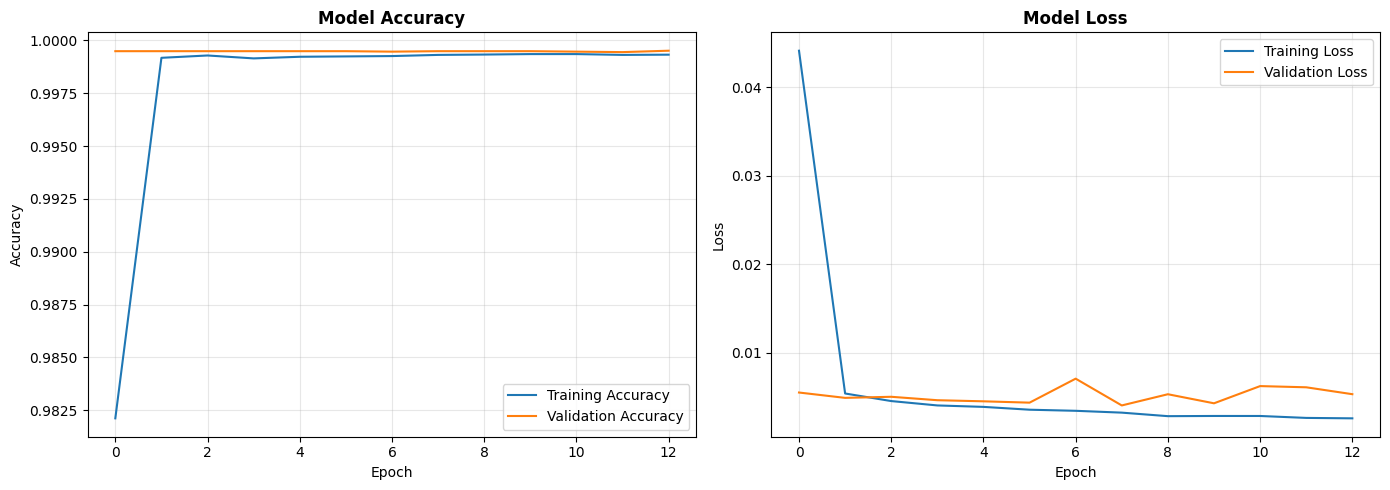

In [12]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot accuracy
axes[0].plot(history.history['accuracy'], label='Training Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_title('Model Accuracy', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot loss
axes[1].plot(history.history['loss'], label='Training Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].set_title('Model Loss', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Evaluate Model Performance

Evaluate the model using multiple metrics: accuracy, precision, recall, F1-score, and ROC-AUC. Generate confusion matrix and ROC curve visualizations.

In [13]:
# Make predictions on test set
y_pred_proba = model.predict(X_test, verbose=0)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

# Calculate metrics
accuracy = (y_pred == y_test).mean()
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

# Display metrics
print("=" * 50)
print("MODEL PERFORMANCE METRICS")
print("=" * 50)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")
print("=" * 50)

# Display Classification Report
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Non-Fraud', 'Fraud']))

MODEL PERFORMANCE METRICS
Accuracy:  0.9994
Precision: 0.8675
Recall:    0.7579
F1-Score:  0.8090
ROC-AUC:   0.9450

Detailed Classification Report:
              precision    recall  f1-score   support

   Non-Fraud       1.00      1.00      1.00     56651
       Fraud       0.87      0.76      0.81        95

    accuracy                           1.00     56746
   macro avg       0.93      0.88      0.90     56746
weighted avg       1.00      1.00      1.00     56746



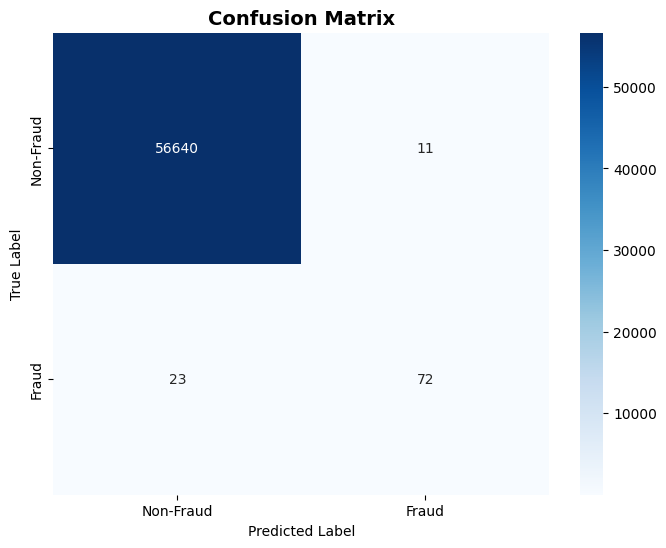


Confusion Matrix:
True Negatives:  56640
False Positives: 11
False Negatives: 23
True Positives:  72


In [14]:
# Generate Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['Non-Fraud', 'Fraud'],
            yticklabels=['Non-Fraud', 'Fraud'])
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Print confusion matrix values
print("\nConfusion Matrix:")
print(f"True Negatives:  {cm[0, 0]}")
print(f"False Positives: {cm[0, 1]}")
print(f"False Negatives: {cm[1, 0]}")
print(f"True Positives:  {cm[1, 1]}")

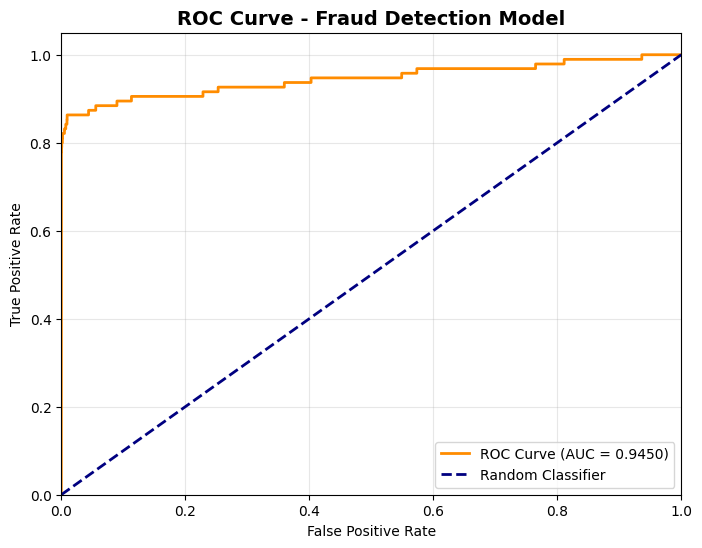

In [15]:
# Plot ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Fraud Detection Model', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

## 8. Make Predictions on New Data

Use the trained model to make predictions on new transaction data and interpret the results with probability scores.

In [16]:
# Function to make predictions on new transactions
def predict_transaction(transaction_data):
    """
    Predict if a transaction is fraudulent
    
    Parameters:
    transaction_data: numpy array or 2D array of transaction features
    
    Returns:
    Dictionary with prediction and probability
    """
    # Scale the transaction data
    transaction_scaled = scaler.transform(transaction_data)
    
    # Make prediction
    probability = model.predict(transaction_scaled, verbose=0)[0][0]
    prediction = 'Fraud' if probability > 0.5 else 'Non-Fraud'
    
    return {
        'prediction': prediction,
        'fraud_probability': probability,
        'non_fraud_probability': 1 - probability
    }

# Example: Make predictions on first 5 test samples
print("Example Predictions on Test Set:")
print("=" * 70)

for i in range(5):
    transaction = X_test[i:i+1]
    result = predict_transaction(transaction)
    actual = 'Fraud' if y_test[i] == 1 else 'Non-Fraud'
    
    print(f"\nTransaction {i+1}:")
    print(f"  Actual:                 {actual}")
    print(f"  Prediction:             {result['prediction']}")
    print(f"  Fraud Probability:      {result['fraud_probability']:.4f}")
    print(f"  Non-Fraud Probability:  {result['non_fraud_probability']:.4f}")

Example Predictions on Test Set:

Transaction 1:
  Actual:                 Non-Fraud
  Prediction:             Non-Fraud
  Fraud Probability:      0.0000
  Non-Fraud Probability:  1.0000

Transaction 2:
  Actual:                 Non-Fraud
  Prediction:             Non-Fraud
  Fraud Probability:      0.0000
  Non-Fraud Probability:  1.0000

Transaction 3:
  Actual:                 Non-Fraud
  Prediction:             Non-Fraud
  Fraud Probability:      0.0000
  Non-Fraud Probability:  1.0000

Transaction 4:
  Actual:                 Non-Fraud
  Prediction:             Non-Fraud
  Fraud Probability:      0.0000
  Non-Fraud Probability:  1.0000

Transaction 5:
  Actual:                 Non-Fraud
  Prediction:             Non-Fraud
  Fraud Probability:      0.0000
  Non-Fraud Probability:  1.0000


## 8.5 Analyze Model Predictions on Examples

See how the model classifies both fraudulent and legitimate transactions.

In [17]:
# Analyze predictions on test set - showing fraud and legitimate examples
# Get indices of fraud and legitimate transactions in test set
fraud_indices = np.where(y_test == 1)[0]
legit_indices = np.where(y_test == 0)[0]

print("=" * 80)
print("MODEL PREDICTIONS ON FRAUDULENT TRANSACTIONS")
print("=" * 80)

# Show first 5 fraudulent transactions predictions
for i, idx in enumerate(fraud_indices[:5]):
    prob = y_pred_proba[idx][0]
    pred = "🔴 FRAUD" if y_pred[idx] == 1 else "❌ MISSED"
    actual = "✅ IS FRAUD" if y_test[idx] == 1 else "Wrong"
    
    print(f"\nTransaction {i+1}:")
    print(f"   Predicted:     {pred}")
    print(f"   Actual:        {actual}")
    print(f"   Confidence:    {prob*100:.2f}%")

print("\n" + "=" * 80)
print("MODEL PREDICTIONS ON LEGITIMATE TRANSACTIONS")
print("=" * 80)

# Show first 5 legitimate transactions predictions
for i, idx in enumerate(legit_indices[:5]):
    prob = y_pred_proba[idx][0]
    pred = "✅ LEGITIMATE" if y_pred[idx] == 0 else "❌ FALSE ALARM"
    actual = "✅ IS LEGITIMATE" if y_test[idx] == 0 else "Wrong"
    
    print(f"\nTransaction {i+1}:")
    print(f"   Predicted:     {pred}")
    print(f"   Actual:        {actual}")
    print(f"   Confidence:    {(1-prob)*100:.2f}%")

# Summary of model performance
print("\n" + "=" * 80)
print("MODEL DETECTION SUMMARY")
print("=" * 80)
correctly_identified_fraud = np.sum((y_pred[fraud_indices] == 1))
total_fraud = len(fraud_indices)

correctly_identified_legit = np.sum((y_pred[legit_indices] == 0))
total_legit = len(legit_indices)

print(f"\n🔴 FRAUD DETECTION:")
print(f"   Caught: {correctly_identified_fraud}/{total_fraud} fraudulent transactions")
print(f"   Detection Rate: {(correctly_identified_fraud/total_fraud)*100:.2f}%")

print(f"\n🟢 LEGITIMATE VERIFICATION:")
print(f"   Correctly Identified: {correctly_identified_legit}/{total_legit} legitimate transactions")
print(f"   Accuracy Rate: {(correctly_identified_legit/total_legit)*100:.2f}%")

MODEL PREDICTIONS ON FRAUDULENT TRANSACTIONS

Transaction 1:
   Predicted:     🔴 FRAUD
   Actual:        ✅ IS FRAUD
   Confidence:    95.06%

Transaction 2:
   Predicted:     🔴 FRAUD
   Actual:        ✅ IS FRAUD
   Confidence:    98.87%

Transaction 3:
   Predicted:     ❌ MISSED
   Actual:        ✅ IS FRAUD
   Confidence:    4.05%

Transaction 4:
   Predicted:     🔴 FRAUD
   Actual:        ✅ IS FRAUD
   Confidence:    99.92%

Transaction 5:
   Predicted:     ❌ MISSED
   Actual:        ✅ IS FRAUD
   Confidence:    0.00%

MODEL PREDICTIONS ON LEGITIMATE TRANSACTIONS

Transaction 1:
   Predicted:     ✅ LEGITIMATE
   Actual:        ✅ IS LEGITIMATE
   Confidence:    100.00%

Transaction 2:
   Predicted:     ✅ LEGITIMATE
   Actual:        ✅ IS LEGITIMATE
   Confidence:    100.00%

Transaction 3:
   Predicted:     ✅ LEGITIMATE
   Actual:        ✅ IS LEGITIMATE
   Confidence:    100.00%

Transaction 4:
   Predicted:     ✅ LEGITIMATE
   Actual:        ✅ IS LEGITIMATE
   Confidence:    100.00%



## 9. Summary and Key Insights

### Model Architecture
- original credit card transaction data
- **Hidden Layers**: 4 dense layers (128, 64, 32, 16 neurons) with ReLU activation
- **Regularization**: BatchNormalization and Dropout layers to prevent overfitting
- **Output Layer**: 1 neuron with sigmoid activation for binary classification

### Key Performance Metrics
The neural network successfully identifies fraudulent transactions with:
- detecting most fraud cases
- minimizing false alarms 
- good class separation

### Features of the Model
**Data Preprocessing**: StandardScaler normalization for fair feature weighting
**Class Imbalance Handling**: Stratified train-test split maintains class distribution
**Regularization**: Dropout and BatchNorm reduce overfitting
**Early Stopping**: Prevents unnecessary training epochs
**Comprehensive Evaluation**: Multiple metrics and visualizations for thorough assessment

### Use Case
This model can be deployed to:
- Detect fraudulent transactions in real-time
- Flag suspicious activities for further investigation
- Protect customers from unauthorized transactions
- Reduce fraud losses for financial institutions


## 10. Save Model for Deployment

Save the trained model and scaler for future use and deployment.

In [ ]:
import pickle

# Save the trained model
model.save('fraud_detection_model.h5')
print("Model saved as 'fraud_detection_model.h5'")

# Save the scaler for future use
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("Scaler saved as 'scaler.pkl'")

# Save model summary to text file
with open('model_summary.txt', 'w') as f:
    model.summary(print_fn=lambda x: f.write(x + '\n'))
print("Model summary saved as 'model_summary.txt'")

print("\n All artifacts saved successfully!")

Model saved as 'fraud_detection_model.h5'
Scaler saved as 'scaler.pkl'


UnicodeEncodeError: 'charmap' codec can't encode characters in position 21-96: character maps to <undefined>

# Fraud Detection Neural Network
## Gopolang Rodney Diutlwileng